# **Feature Engineering**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Machine Learning/Python codes/Python Libraries Basics/covid_toy.csv')
df.shape

(100, 6)

In [ ]:
df.sample(6)
df.isnull().sum() # fever has 10 missing values

,0
age,0
gender,0
fever,10
cough,0
city,0
has_covid,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['has_covid']),df['has_covid'],test_size=0.25)

In [ ]:
X_train.head()

,age,gender,fever,cough,city
20,12,Male,98.0,Strong,Bangalore
2,42,Male,101.0,Mild,Delhi
76,80,Male,100.0,Mild,Bangalore
99,10,Female,98.0,Strong,Kolkata
13,64,Male,102.0,Mild,Bangalore


In [ ]:
# Filling thoose missing values
si=SimpleImputer()
X_train_fever=si.fit_transform(X_train[['fever']])
X_test_fever=si.fit_transform(X_test[['fever']])
print(X_train_fever.shape)
print(X_test_fever.shape)

(75, 1)
(25, 1)


In [ ]:
# Applying Ordinal Encoding to Cough
oe=OrdinalEncoder(categories=[['Mild','Strong']])
X_train_cough=oe.fit_transform(X_train[['cough']])
X_test_cough=oe.fit_transform(X_test[['cough']])
X_test_cough.shape

(25, 1)

In [ ]:
# Applying OneHot Encoder to City, Gender
ohe=OneHotEncoder(drop='first',sparse_output=False)
X_train_gender_city=ohe.fit_transform(X_train[['gender','city']])
X_test_gender_city=ohe.fit_transform(X_test[['gender','city']])
X_test_gender_city

array([[0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 1., 0., 0.],
       [1., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 1., 0.],
       [1., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 1., 0.],
       [1., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
#Extracting Age
X_train_age=X_train.drop(columns=['gender','fever','cough','city']).values
X_test_age=X_test.drop(columns=['gender','fever','cough','city']).values
X_test_age.shape

(25, 1)

In [ ]:
# Concatenating all coloumns
X_train_transformed=np.concatenate((X_train_age,X_train_fever,X_train_gender_city,X_train_cough),axis=1)
X_test_transformed = np.concatenate((X_test_age,X_test_fever,X_test_gender_city,X_test_cough),axis=1)

In [ ]:
# Convert to Dataframe
# Create a list of column names for the transformed DataFrame
# The order should match the concatenation order in X_train_transformed
new_column_names = ['age', 'fever'] + list(ohe.get_feature_names_out()) + ['cough']

X_train_transformed_df=pd.DataFrame(X_train_transformed, columns=new_column_names)
X_test_transformed_df=pd.DataFrame(X_test_transformed, columns=new_column_names)
X_test_transformed_df.sample(4)

,age,fever,gender_Male,city_Delhi,city_Kolkata,city_Mumbai,cough
17,16.0,104.0,1.0,0.0,1.0,0.0,0.0
24,12.0,104.0,0.0,0.0,0.0,0.0,0.0
13,56.0,104.0,0.0,0.0,0.0,0.0,1.0
0,82.0,102.0,0.0,0.0,1.0,0.0,1.0


# **Mentos Zindagi**

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
transformer = ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['fever']),
    ('tnf2',OrdinalEncoder(categories=[['Mild','Strong']]),['cough']),
    ('tnf3',OneHotEncoder(sparse_output=False,drop='first'),['gender','city'])
],remainder='passthrough')

In [ ]:
transformer.fit_transform(X_train).shape
transformer.transform(X_test).shape

(25, 7)

In [ ]:
# Converting to Dataframe
df_train=pd.DataFrame(transformer.fit_transform(X_train),columns=transformer.get_feature_names_out())
df_test=pd.DataFrame(transformer.transform(X_test),columns=transformer.get_feature_names_out())
df_train.sample(5)

,tnf1__fever,tnf2__cough,tnf3__gender_Male,tnf3__city_Delhi,tnf3__city_Kolkata,tnf3__city_Mumbai,remainder__age
29,99.000000,0.0,1.0,0.0,0.0,0.0,65.0
68,100.757576,0.0,0.0,0.0,0.0,0.0,84.0
69,104.000000,0.0,1.0,0.0,0.0,0.0,51.0
17,98.000000,0.0,1.0,0.0,0.0,0.0,73.0
15,98.000000,0.0,0.0,1.0,0.0,0.0,80.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


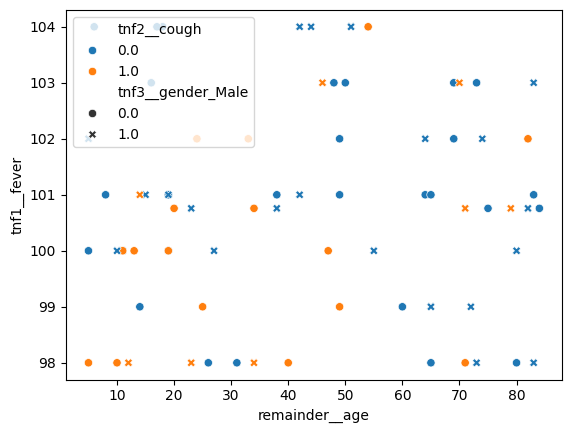

In [ ]:
sns.scatterplot(data=df_train,x='remainder__age',y='tnf1__fever',hue='tnf2__cough',style='tnf3__gender_Male')
plt.show()

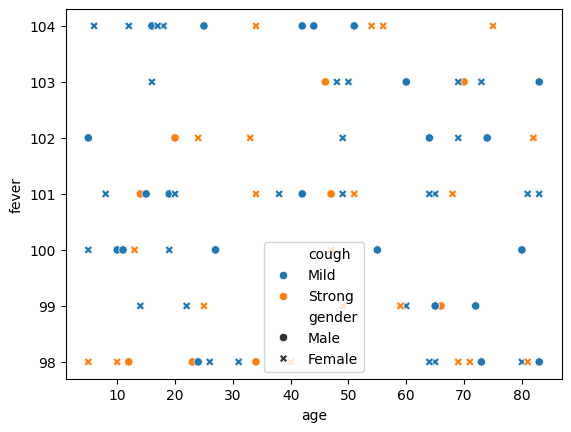

In [ ]:
sns.scatterplot(data=df,x='age',y='fever',hue='cough',style='gender')
plt.show()